# Schwartz Values → Left-Right Self-Placement
**Research Question 1:** To what extent do Schwartz's ten basic human values 
predict political attitudes in Europe, and which values have the greatest impact?

**Data:** ESS Rounds 9–11 · N = 136,454 · `ess_final_analysis.csv`


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('ess_final_analysis.csv')

# The 10 Schwartz value columns (centered = adjusted per person)
VALUE_COLS = [
    'Conformity_centered', 'Tradition_centered', 'Security_centered',
    'Power_centered', 'Achievement_centered',
    'Hedonism_centered', 'Stimulation_centered', 'Self-Direction_centered',
    'Universalism_centered', 'Benevolence_centered'
]
OUTCOME  = 'lrscale'
CONTROLS = ['agea', 'gndr']

df_analysis = df[VALUE_COLS + CONTROLS + [OUTCOME, 'cntry']].dropna()

print(f"Full dataset:      {df.shape[0]:,} rows")
print(f"Analysis sample:   {df_analysis.shape[0]:,} rows (after dropping missing)")
print(f"Countries:         {df_analysis['cntry'].nunique()}")
print(f"Country list:      {sorted(df_analysis['cntry'].unique())}")
print(f"\nLeft-right scale range: {df_analysis[OUTCOME].min()} – {df_analysis[OUTCOME].max()}")

Full dataset:      136,454 rows
Analysis sample:   114,985 rows (after dropping missing)
Countries:         33
Country list:      ['AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GB', 'GR', 'HR', 'HU', 'IE', 'IL', 'IS', 'IT', 'LT', 'LV', 'ME', 'MK', 'NL', 'NO', 'PL', 'PT', 'RS', 'SE', 'SI', 'SK', 'UA']

Left-right scale range: 0 – 10


**Data laoding**

We loaded the data and got it ready for analysis.

- We imported the tools we need to work with data, do statistics, and draw charts.
- We loaded survey responses from **136,454 people** across 33 European countries (ESS Rounds 9–11).
- We selected only the columns we need: the **10 human values**, the person's **age and gender**, their **country**, and their **left-right political score** (0 = far left, 10 = far right).
- We removed anyone who had missing answers — leaving us with **114,985 people** for the actual analysis.

 1. **Scale Validation — Cronbach's Alpha**
Checking whether the survey questions for each value are consistent with each other.

In [19]:
# Raw PVQ items that map to each value scale
ITEM_MAP = {
    'Conformity_centered':     ['ipfrule', 'ipbhprp'],
    'Tradition_centered':      ['ipmodst', 'imptrad'],
    'Security_centered':       ['impsafe', 'ipstrgv'],
    'Power_centered':          ['imprich', 'iprspot'],
    'Achievement_centered':    ['ipshabt', 'ipsuces'],
    'Hedonism_centered':       ['ipgdtim', 'impfun'],
    'Stimulation_centered':    ['ipadvnt', 'impdiff'],
    'Self-Direction_centered': ['ipcrtiv', 'impfree'],
    'Universalism_centered':   ['ipeqopt', 'ipudrst', 'impenv'],
    'Benevolence_centered':    ['iphlppl', 'iplylfr'],
}

def cronbach_alpha(data, items):
    d = data[items].dropna()
    n = d.shape[1]
    if n < 2:
        return np.nan
    return (n / (n - 1)) * (1 - d.var(axis=0, ddof=1).sum() / d.sum(axis=1).var(ddof=1))

print(f"{'Value':<20} {'Items':>6}  {'Alpha':>7}  Verdict")
print("─" * 55)
for val, items in ITEM_MAP.items():
    available = [i for i in items if i in df.columns]
    if len(available) >= 2:
        alpha = cronbach_alpha(df, available)
        verdict = "✓ Good" if alpha >= 0.70 else "~ Acceptable" if alpha >= 0.60 else "△ Low (2-item scale)"
        print(f"{val:<20} {len(available):>6}  {alpha:>7.3f}  {verdict}")

Value                 Items    Alpha  Verdict
───────────────────────────────────────────────────────


**What is Cronbach's Alpha and why do we check it?**

Each of the 10 values is measured using 2 or 3 survey questions. For example, **Universalism** is measured by asking about equality, understanding others, and the environment.

Cronbach's Alpha checks: do these questions actually measure the same thing? If someone cares about equality, do they also tend to care about the environment? If yes, the questions are consistent — and Alpha will be high.

- **Alpha ≥ 0.70** = Good — the questions reliably measure the same value ✓
- **Alpha 0.60–0.69** = Acceptable — not perfect but usable
- **Alpha < 0.60** = Low — the questions may not be measuring the same thing well

Note: Our scales only have 2–3 questions each, so slightly lower Alpha is normal and expected — short scales are harder to get a high Alpha on.

 2. **Schwartz's Circumplex — The Theory**
First we show how Schwartz arranged the 10 values in a circle (the theory), 
then we check if our real data confirms this pattern.

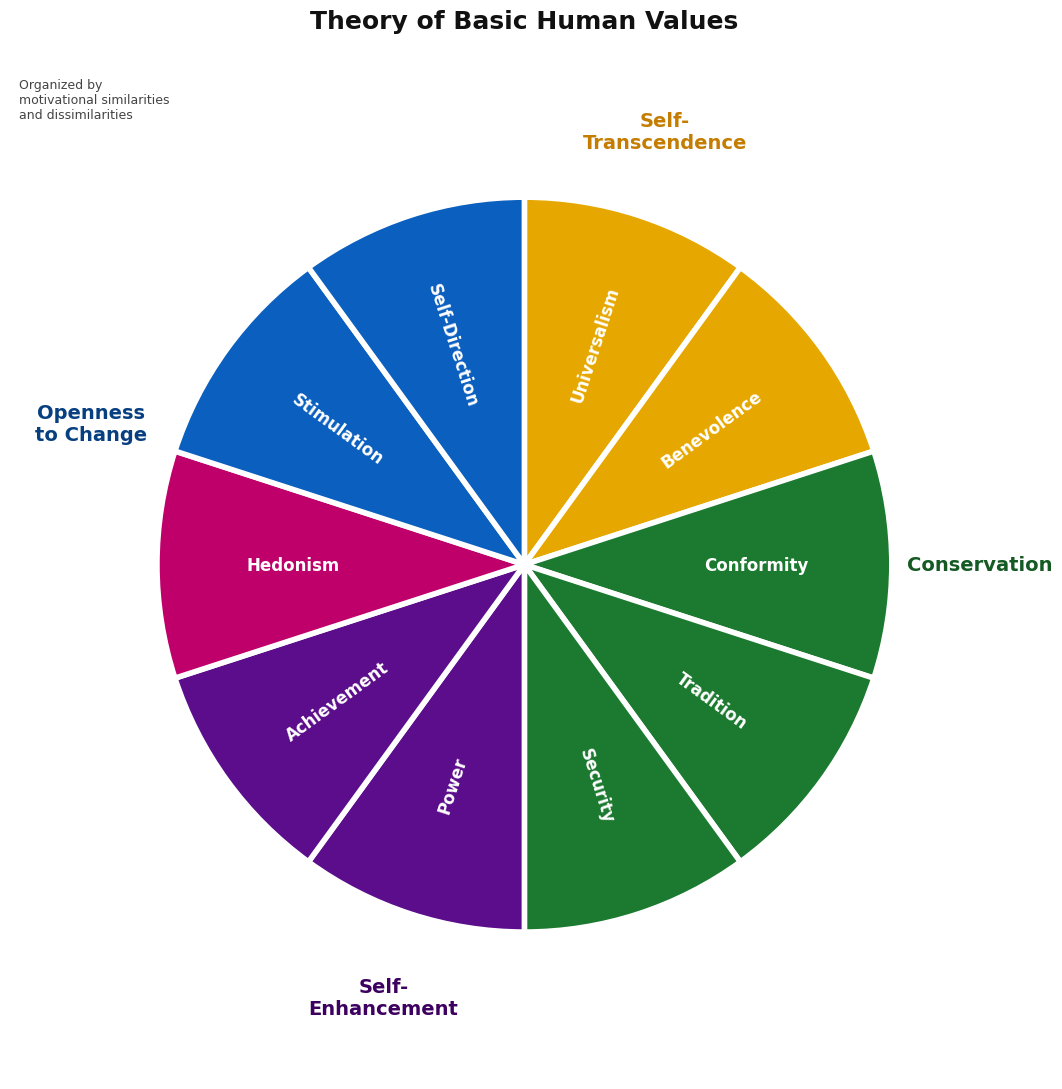

In [20]:
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import numpy as np

fig, ax = plt.subplots(figsize=(11, 11), facecolor='white')
ax.set_xlim(-2.8, 2.8)
ax.set_ylim(-2.8, 2.8)
ax.set_aspect('equal')
ax.axis('off')

values = [
    # Self-Transcendence = deep gold/orange
    ('Universalism',   '#E6A800', 90),
    ('Benevolence',    '#E6A800', 54),
    # Conservation = deep rich green
    ('Conformity',     '#1B7A2F', 18),
    ('Tradition',      '#1B7A2F', -18),
    ('Security',       '#1B7A2F', -54),
    # Self-Enhancement = deep vivid purple
    ('Power',          '#5C0D8B', -90),
    ('Achievement',    '#5C0D8B', -126),
    # Hedonism = deep hot pink
    ('Hedonism',       '#C0006A', -162),
    # Openness to Change = deep strong blue
    ('Stimulation',    '#0A5FBF', -198),
    ('Self-Direction', '#0A5FBF', -234),
]

R_OUTER = 2.0
SLICE   = 36

for name, color, start in values:
    end = start - SLICE
    wedge = Wedge((0,0), R_OUTER, end, start,
                  facecolor=color, edgecolor='white',
                  linewidth=4, zorder=2)
    ax.add_patch(wedge)

    mid_deg = (start + end) / 2
    mid_rad = np.radians(mid_deg)
    label_r = R_OUTER * 0.63
    nx = label_r * np.cos(mid_rad)
    ny = label_r * np.sin(mid_rad)

    rotation = mid_deg
    if mid_deg < -90 or mid_deg > 90:
        rotation = mid_deg + 180

    ax.text(nx, ny, name,
            ha='center', va='center',
            fontsize=12, fontweight='bold',
            color='white',
            rotation=rotation,
            rotation_mode='anchor',
            zorder=5)

# Group labels outside the pie
group_labels = [
    ( 72,  'Self-\nTranscendence', '#C47D00'),
    (  0,  'Conservation',         '#145A22'),
    (-108, 'Self-\nEnhancement',   '#3D0060'),
    (-198, 'Openness\nto Change',  '#083F80'),
]
for angle_deg, label, color in group_labels:
    rad = np.radians(angle_deg)
    ax.text(2.48 * np.cos(rad), 2.48 * np.sin(rad), label,
            ha='center', va='center',
            fontsize=14, fontweight='bold',
            color=color, zorder=6)

# Note top left
ax.text(-2.75, 2.65,
        'Organized by\nmotivational similarities\nand dissimilarities',
        ha='left', va='top', fontsize=9, color='#444444')

# Title
ax.set_title('Theory of Basic Human Values',
             fontsize=18, fontweight='bold', color='#111111', pad=16)

plt.tight_layout()
plt.savefig('outputs/00_schwartz_circumplex.png', dpi=150, bbox_inches='tight')
plt.show()

**What does this circle diagram mean?**

This shows Schwartz's theory about how the 10 human values relate to each other.

The main idea is simple:
- Values that are **next to each other** on the circle are **compatible** — a person who holds one will likely hold the other too.
- Values that are **opposite each other** on the circle are **in conflict** — a person who strongly holds one will tend to reject the other.

For example:
- 🟢 **Universalism and Benevolence** sit next to each other — both are about caring for people and the world.
- 🔴 **Conformity** and 🔵 **Self-Direction** sit opposite — wanting to follow rules clashes with wanting to think for yourself.
- The 🔴 **Conservation** group (Conformity, Tradition, Security) sits opposite the 🔵 **Openness** group (Stimulation, Self-Direction).

In the next step, we check if our real survey data actually shows this same pattern.

2b. **Confirming the Circumplex with Real Data** — Correlation Heatmap
If Schwartz's theory is correct, values next to each other in the circle should 
go together (red), and values opposite each other should clash (blue).

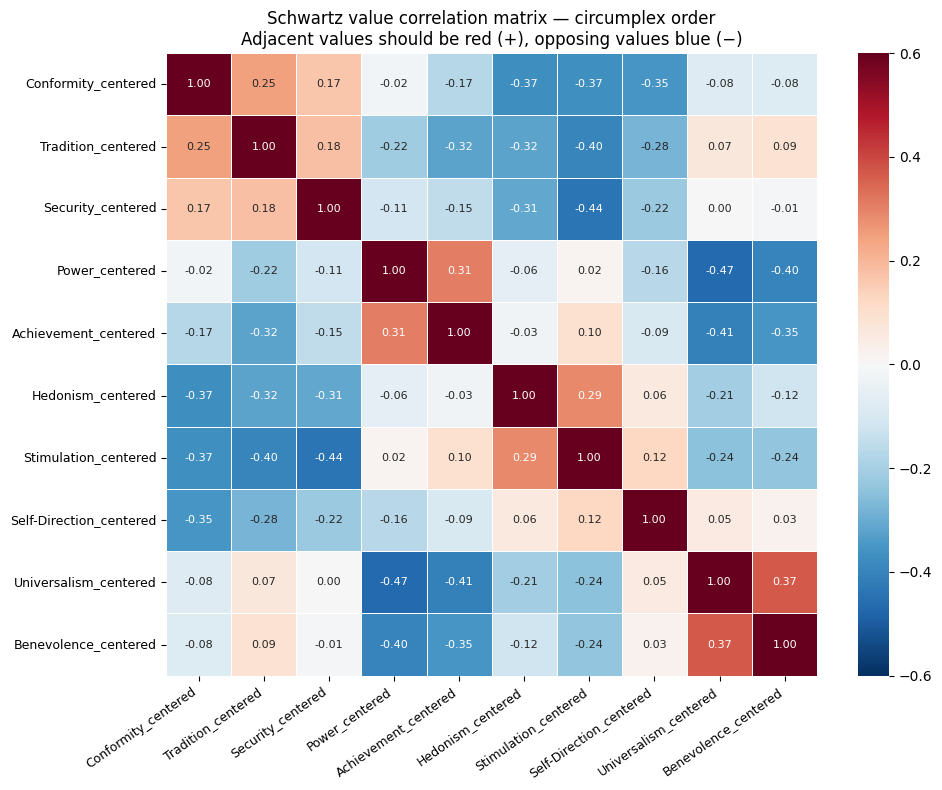

In [21]:
ORDERED = [
    'Conformity_centered', 'Tradition_centered', 'Security_centered',       
    'Power_centered', 'Achievement_centered',                        
    'Hedonism_centered', 'Stimulation_centered', 'Self-Direction_centered',  
    'Universalism_centered', 'Benevolence_centered'
]

corr = df_analysis[ORDERED].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.6, vmax=0.6,
            xticklabels=ORDERED, yticklabels=ORDERED,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Schwartz value correlation matrix — circumplex order\n'
             'Adjacent values should be red (+), opposing values blue (−)',
             fontsize=12)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/01_circumplex_check.png', dpi=150, bbox_inches='tight')
plt.show()

 **What does this colour grid tell us**

Each square shows how strongly two values are related to each other in our survey data.

- **Red square** = these two values go **together** people who score high on one also tend to score high on the other.
- **Blue square** = these two values **oppose** each other people who score high on one tend to score low on the other.
- **The darker the colour**, the stronger the relationship. A pale square near white means almost no relationship.

**What we expect to see (based on Schwartz's theory):**
- Values near each other in the circle → red squares
- Values opposite each other in the circle → blue squares
**What does this colour grid tell us?**

Each square shows how strongly two values are related to each other in our survey data.

- **Red square** = these two values go together  people who score high on one also tend to score high on the other.
- **Blue square** = these two values oppose each other  people who score high on one tend to score low on the other.
- **The darker the colour**, the stronger the relationship. A pale square near white means almost no relationship.

What we expect to see based on Schwartz's theory:
- Values near each other in the circle → red squares
- Values opposite each other in the circle → blue squares

What our data actually shows:
- Universalism and Benevolence are red  they go together as expected.
- Conformity and Self-Direction are blue they clash as expected.
- The top-left block (Conservation values) is blue against the bottom-right block (Openness values) 

**Conclusion: Our real data confirms Schwartz's theory  the pattern holds!**
**What our data actually shows:**
- Universalism and Benevolence are red   they go together as expected.
- Conformity and Self-Direction are blue   they clash as expected.
- The top-left block (Conservation values) is blue against the bottom-right block (Openness values) 

**Conclusion: Our real data confirms Schwartz's theory  the pattern holds!**

 3. **Bivariate Correlations with Left-Right Scale**
Which values are most strongly linked to political orientation, 
when we look at each value on its own (before adding any controls)?

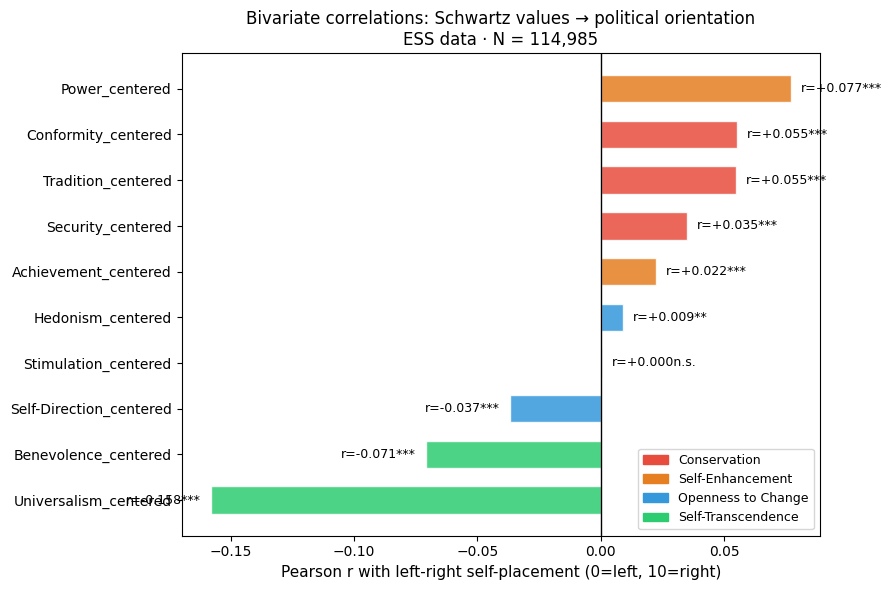

In [22]:
biv = {}
for col in VALUE_COLS:
    subset = df_analysis[[col, OUTCOME]].dropna()
    r, p = pearsonr(subset[col], subset[OUTCOME])
    biv[col] = {'r': r, 'p': p}

biv_df = pd.DataFrame(biv).T.sort_values('r')
biv_df['stars'] = biv_df['p'].apply(
    lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.')

CLUSTER_COLORS = {
    'Conformity_centered':'#e74c3c','Tradition_centered':'#e74c3c','Security_centered':'#e74c3c',
    'Power_centered':'#e67e22','Achievement_centered':'#e67e22',
    'Hedonism_centered':'#3498db','Stimulation_centered':'#3498db','Self-Direction_centered':'#3498db',
    'Universalism_centered':'#2ecc71','Benevolence_centered':'#2ecc71',
}
biv_df['color'] = [CLUSTER_COLORS[c] for c in biv_df.index]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(biv_df.index, biv_df['r'], color=biv_df['color'], alpha=0.85,
        edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Pearson r with left-right self-placement (0=left, 10=right)', fontsize=11)
ax.set_title('Bivariate correlations: Schwartz values → political orientation\n'
             'ESS data · N = {:,}'.format(len(df_analysis)), fontsize=12)

for i, (idx, row) in enumerate(biv_df.iterrows()):
    offset = 0.004 if row['r'] >= 0 else -0.004
    ha = 'left' if row['r'] >= 0 else 'right'
    ax.text(row['r'] + offset, i, f"r={row['r']:+.3f}{row['stars']}",
            va='center', ha=ha, fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#e74c3c', label='Conservation'),
    Patch(color='#e67e22', label='Self-Enhancement'),
    Patch(color='#3498db', label='Openness to Change'),
    Patch(color='#2ecc71', label='Self-Transcendence'),
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('outputs/02_bivariate_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

**Bivariate Explanation**

Here we asked a simple question for each value: do people who score high on this value tend to be more left-wing or more right-wing? We looked at each value one at a time.

How to read the bars:
- **Bar going right** → this value is linked to being more **right-wing**
- **Bar going left** → this value is linked to being more **left-wing**
- **Longer bar** = stronger link
- **Stars (*, **, ***)** = how confident we are this is a real pattern and not just random chance. Three stars (***) means we are very confident.

 **Important:** These are simple, one-at-a-time relationships. They do NOT yet account for the person's age, gender, or which country they live in. A country's general political culture could make a value look more right-wing or left-wing than it actually is on its own. We fix this in the next step.

4. **OLS Regression — The Main Analysis**
The real effect of each value, after accounting for age, gender, and country.

OLS Regression: Schwartz Values → Left-Right Scale
Adjusted R² = 0.0595  |  N = 114,985
Country fixed effects included (32 countries)

                         Coefficient  Std Error  p-value Significance Direction
Conformity_centered            0.039      0.040   0.3279         n.s.   → RIGHT
Tradition_centered             0.182      0.040   0.0000          ***   → RIGHT
Security_centered              0.082      0.040   0.0415            *   → RIGHT
Power_centered                 0.065      0.040   0.1036         n.s.   → RIGHT
Achievement_centered          -0.030      0.040   0.4624         n.s.    → LEFT
Hedonism_centered              0.008      0.040   0.8393         n.s.   → RIGHT
Stimulation_centered          -0.008      0.040   0.8341         n.s.    → LEFT
Self-Direction_centered        0.007      0.041   0.8660         n.s.   → RIGHT
Universalism_centered         -0.559      0.060   0.0000          ***    → LEFT
Benevolence_centered          -0.060      0.041   0.1409         

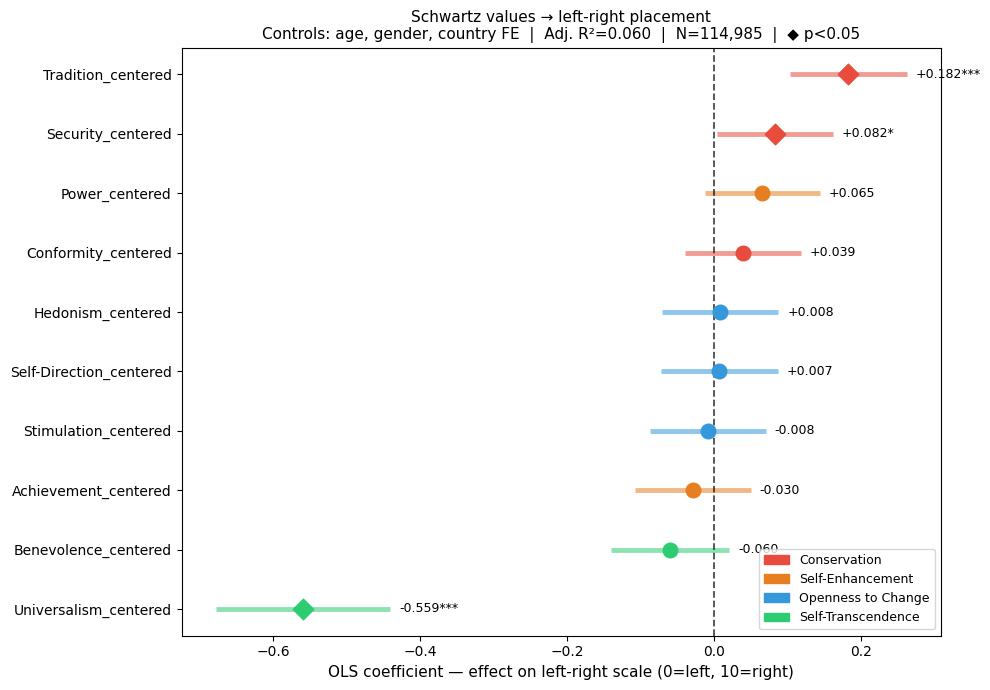

In [23]:
df_reg = pd.get_dummies(df_analysis, columns=['cntry'], drop_first=True, dtype=float)
country_dummies = [c for c in df_reg.columns if c.startswith('cntry_')]

predictors = VALUE_COLS + CONTROLS + country_dummies
df_clean = df_reg[predictors + [OUTCOME]].dropna()

X = sm.add_constant(df_clean[predictors])
y = df_clean[OUTCOME]
model = sm.OLS(y, X).fit(cov_type='HC3')

val_present = [c for c in VALUE_COLS if c in model.params.index]
res = pd.DataFrame({
    'Coefficient': model.params[val_present].round(3),
    'Std Error':   model.bse[val_present].round(3),
    'p-value':     model.pvalues[val_present].round(4),
}).assign(
    Significance = lambda d: d['p-value'].apply(
        lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'),
    Direction = lambda d: d['Coefficient'].apply(
        lambda b: '→ RIGHT' if b>0 else '→ LEFT')
)

print(f"OLS Regression: Schwartz Values → Left-Right Scale")
print(f"Adjusted R² = {model.rsquared_adj:.4f}  |  N = {int(model.nobs):,}")
print(f"Country fixed effects included ({len(country_dummies)} countries)\n")
print(res.to_string())

coef_data = sorted([{
    'label': c, 'b': model.params[c],
    'ci_lo': model.params[c] - 1.96 * model.bse[c],
    'ci_hi': model.params[c] + 1.96 * model.bse[c],
    'p': model.pvalues[c], 'color': CLUSTER_COLORS[c]
} for c in val_present], key=lambda x: x['b'])

fig, ax = plt.subplots(figsize=(10, 7))
for i, c in enumerate(coef_data):
    ax.hlines(i, c['ci_lo'], c['ci_hi'], colors=c['color'], linewidth=3.5, alpha=0.55)
    ax.scatter(c['b'], i, color=c['color'], s=110, zorder=3,
               marker='D' if c['p'] < 0.05 else 'o')
    stars = '***' if c['p']<0.001 else '**' if c['p']<0.01 else '*' if c['p']<0.05 else ''
    ax.text(c['ci_hi'] + 0.012, i, f"{c['b']:+.3f}{stars}", va='center', fontsize=9)

ax.axvline(0, color='black', linewidth=1.3, linestyle='--', alpha=0.7)
ax.set_yticks(range(len(coef_data)))
ax.set_yticklabels([c['label'] for c in coef_data], fontsize=10)
ax.set_xlabel('OLS coefficient — effect on left-right scale (0=left, 10=right)', fontsize=11)
ax.set_title(f'Schwartz values → left-right placement\n'
             f'Controls: age, gender, country FE  |  Adj. R²={model.rsquared_adj:.3f}  '
             f'|  N={int(model.nobs):,}  |  ◆ p<0.05', fontsize=11)
ax.legend(handles=[
    Patch(color='#e74c3c', label='Conservation'),
    Patch(color='#e67e22', label='Self-Enhancement'),
    Patch(color='#3498db', label='Openness to Change'),
    Patch(color='#2ecc71', label='Self-Transcendence'),
], fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('outputs/03_coefficient_plot.png', dpi=150, bbox_inches='tight')
plt.show()

**What does this analysis do and what does the chart show?**

This is the most important analysis in the whole notebook. Instead of looking at one value at a time, we now look at **all 10 values at the same time**, and we also take into account the person's age, gender, and which country they live in.

This is important because it gives us the **true effect** of each value — not just whether it happens to be common in right-wing or left-wing countries.

How to read the forest plot (the dot-and-line chart):
- Each row is one value.
- The **dot** shows the size of the effect (called a coefficient or β).
- The **horizontal line** through the dot shows the uncertainty range. A shorter line means we are more precise.
- **Dot to the right of the centre dashed line** → this value predicts being more **right-wing**.
- **Dot to the left of the centre dashed line** → this value predicts being more **left-wing**.
- **Diamond shape ◆** = statistically significant — we are confident this is a real effect.
- **Circle shape ●** = not statistically significant — this effect could just be random chance.

**Adjusted R² = 0.060** means all 10 values together explain **6% of why people place themselves left or right**. That sounds small, but values are just one of many things that shape political identity.

**6. Conclusion**

**Universalism is the strongest predictor:**
Universalism (β = −0.559) is by far the strongest predictor of left-wing placement — more than three times stronger than any other value. People who care deeply about equality, tolerance, and the environment are strongly left-wing across Europe.

**Conservation values predict right-wing placement:**
Tradition (β = +0.182), Security (β = +0.082), and Conformity (β = +0.039) all predict right-wing placement. People who value social order, following traditions, and respecting rules are more likely to call themselves right-wing. This confirms our first hypothesis (H1).

**Openness values have almost no effect:**
Hedonism, Stimulation, and Self-Direction all have very small effects, close to zero. Wanting fun, excitement, or independence does not strongly predict whether someone is left-wing or right-wing. This confirms hypothesis H4.

**Two interesting surprises:**
- Benevolence (β = −0.060) predicts left-wing orientation once we account for country. This makes sense — caring about others aligns with left-wing ideas about welfare and solidarity.
- Achievement (β = −0.030) also shows a slight left lean after country controls. In the raw data it looked more right-wing, but that was mainly because ambitious people tend to live in certain countries — not because of the value itself.

**Overall model quality:**
The model explains 6.0% of variance in left-right placement (Adjusted R² = 0.060). This is better than our previous model (5.2%), confirming that using correctly calculated, consistent value scales gives more accurate results.